In [84]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [85]:
dfenergy = pd.read_csv("/content/alltypesofRegression/train_energy_data.csv")
dfenergy.head()

,Building Type,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Day of Week,Energy Consumption
0,Residential,7063,76,10,29.84,Weekday,2713.95
1,Commercial,44372,66,45,16.72,Weekday,5744.99
2,Industrial,19255,37,17,14.30,Weekend,4101.24
3,Residential,13265,14,41,32.82,Weekday,3009.14
4,Commercial,13375,26,18,11.92,Weekday,3279.17


EDA

In [86]:
dfenergy.shape
dfenergy.dtypes
dfenergy.info()
dfenergy.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Building Type        1000 non-null   object 
 1   Square Footage       1000 non-null   int64  
 2   Number of Occupants  1000 non-null   int64  
 3   Appliances Used      1000 non-null   int64  
 4   Average Temperature  1000 non-null   float64
 5   Day of Week          1000 non-null   object 
 6   Energy Consumption   1000 non-null   float64
dtypes: float64(2), int64(3), object(2)
memory usage: 54.8+ KB


,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Energy Consumption
count,1000.000,1000.000000,1000.000000,1000.000000,1000.000000
mean,25462.388,48.372000,25.606000,22.611390,4166.252570
std,14294.554,29.061972,14.105166,7.139943,933.313064
min,560.000,1.000000,1.000000,10.050000,1683.950000
25%,13169.750,22.000000,13.000000,16.475000,3509.482500
50%,25477.000,47.000000,26.000000,22.815000,4175.730000
75%,37446.250,73.250000,38.000000,28.850000,4863.850000
max,49997.000,99.000000,49.000000,34.990000,6530.600000


In [87]:
dfenergy.isnull().sum()

,0
Building Type,0
Square Footage,0
Number of Occupants,0
Appliances Used,0
Average Temperature,0
Day of Week,0
Energy Consumption,0


no missing values

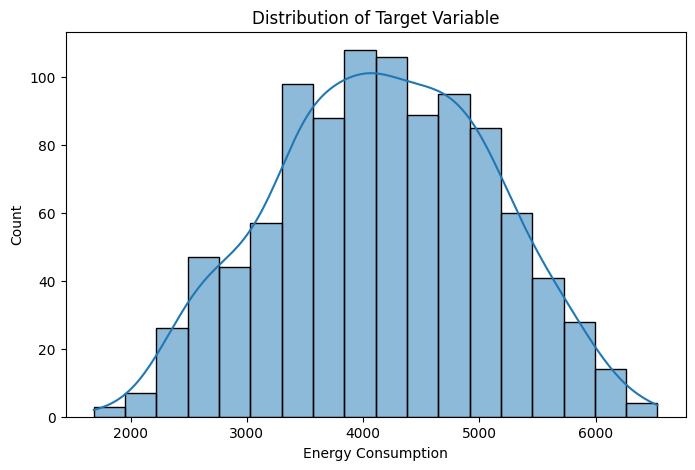

In [88]:
target = "Energy Consumption"
plt.figure(figsize=(8,5))
sns.histplot(dfenergy[target], kde=True)
plt.title("Distribution of Target Variable")
plt.show()

Data is normally distributed

check for multicollinearity for ridge and lasso

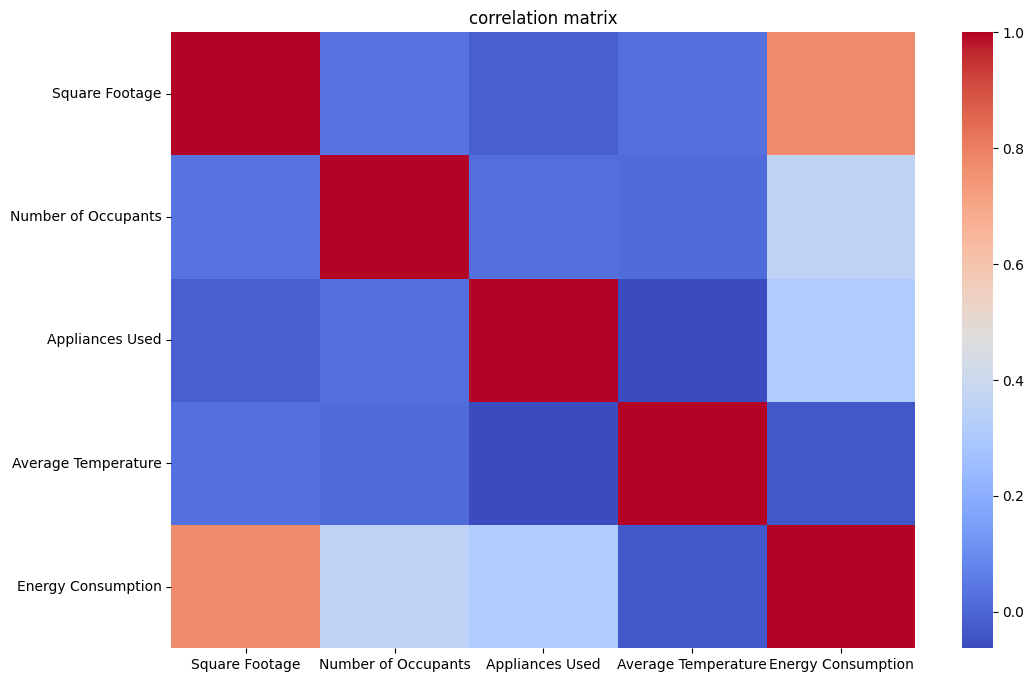

In [89]:
plt.figure(figsize=(12,8))
dfenergyonlynumeric = dfenergy.select_dtypes(include=[np.number])
dfenergy = dfenergyonlynumeric
#done because building type string obj could not be converted to float values
correl = dfenergy.corr() #it will create a correlation matrix
sns.heatmap(correl, cmap="coolwarm")
plt.title("correlation matrix")
plt.show()

In [90]:
goodcorr = correl[(correl>0.8) & (correl<1.0)]
print(goodcorr)
#no good correlation over 0.8

                     Square Footage  ...  Energy Consumption
Square Footage                  NaN  ...                 NaN
Number of Occupants             NaN  ...                 NaN
Appliances Used                 NaN  ...                 NaN
Average Temperature             NaN  ...                 NaN
Energy Consumption              NaN  ...                 NaN

[5 rows x 5 columns]


In [91]:
correlation_with_energyconsumption = correl[target].sort_values()
print(correlation_with_energyconsumption)

Average Temperature   -0.034487
Appliances Used        0.312792
Number of Occupants    0.354485
Square Footage         0.774873
Energy Consumption     1.000000
Name: Energy Consumption, dtype: float64


checking for outliers

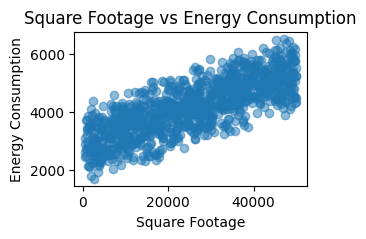

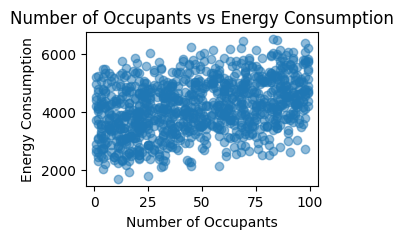

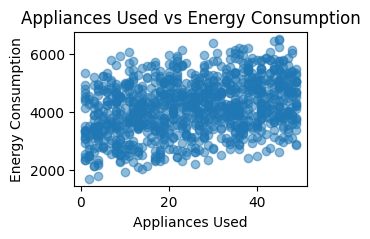

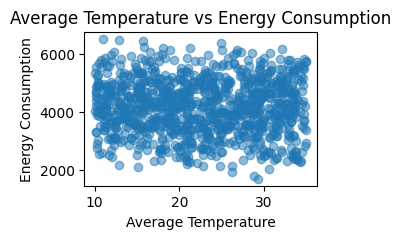

In [92]:
for col in dfenergy.columns:
    if col!=target:
        plt.figure(figsize=(3,2))
        plt.scatter(dfenergy[col],dfenergy[target],alpha=0.5)
        plt.xlabel(col)
        plt.ylabel(target)
        plt.title(f"{col} vs {target}")
        plt.show()
        #no abnormal outlier

Fitting to scale before regularization

In [93]:
X = dfenergy.drop(columns=[target])
y = dfenergy[target]
Xtrain, Xtest, ytrain, ytest = train_test_split(
    X, y, test_size=0.2, random_state=12
)
Scale = StandardScaler()
Xtrain = Scale.fit_transform(Xtrain)
Xtest = Scale.transform(Xtest)
#this is done to maintain consistency in penalties and avoid unfair scaling bw diff regressions

code for regression


Multiple linear

In [94]:
def multiplelinear(X, y, lr=0.01, iter=1000):
    m,n = X.shape
    w = np.zeros(n)
    b = 0
    for _ in range(iter):
        y_pred = X@w + b
        delw = (2/m)*(X.T@(y_pred-y))
        delb = (2/m)*np.sum(y_pred-y)
        w -= lr*delw
        b -= lr*delb

    return w, b

Mutliple Ridge

In [95]:
def ridge(X,y,lambda_=0.1,lr=0.01,iter=1000):
    m,n = X.shape
    w = np.zeros(n)
    b = 0
    for _ in range(iter):
        y_pred = X@w + b
        dw = (2/m)* (X.T@(y_pred - y)) + 2*lambda_ *w
        db = (2/m)* np.sum(y_pred - y)
        w -= lr*dw
        b -= lr*db

    return w, b

Mutliple Lasso

In [96]:
def lasso(X,y,lambda_=0.1,lr=0.01,iter=1000):
    m,n = X.shape
    w = np.zeros(n)
    b = 0
    for _ in range(iter):
        y_pred = X@w+b
        dw = (2/m)*(X.T@(y_pred - y)) + lambda_*np.sign(w)
        db = (2/m)*np.sum(y_pred - y)
        w -= lr*dw
        b -= lr*db

    return w, b

Elastic Net

In [97]:
def elastic_net(X,y,lambda1=0.1,lambda2=0.1,lr=0.01,iter=1000):
    m,n = X.shape
    w = np.zeros(n)
    b = 0
    for _ in range(iter):
        y_pred = X@w+b
        dw = (2/m)*(X.T@(y_pred - y)) \
             + lambda1*np.sign(w) \
             + 2 *lambda2* w
        db = (2/m) *np.sum(y_pred - y)
        w -= lr * dw
        b -= lr * db

    return w, b

checking model scores

In [98]:
from sklearn.metrics import mean_squared_error, r2_score

In [99]:
w_lr,b_lr = multiplelinear(Xtrain,ytrain)

w_ridge,b_ridge = ridge(Xtrain,ytrain,lambda_=0.1)

w_lasso,b_lasso = lasso(Xtrain,ytrain, lambda_=0.1)

w_elastic,b_elastic = elastic_net(Xtrain,ytrain,lambda1=0.1,lambda2=0.1)

In [100]:
y_predlr = Xtest@w_lr + b_lr
y_predridge = Xtest@w_ridge + b_ridge
y_predlasso = Xtest@w_lasso + b_lasso
y_predelastic = Xtest@w_elastic + b_elastic

In [101]:
def evaluate(name,y_true,y_pred):
    print(f"\n{name}")
    print("mse:",mean_squared_error(y_true, y_pred))
    print("r2 score :",r2_score(y_true, y_pred))
evaluate("Multiple linear", ytest, y_predlr)
evaluate("Ridge", ytest, y_predridge)
evaluate("Lasso", ytest, y_predlasso)
evaluate("Elastic net", ytest, y_predelastic)


Multiple linear
mse: 172323.19466523724
r2 score : 0.797560129634532

Ridge
mse: 180804.6933723756
r2 score : 0.7875963316553135

Lasso
mse: 172321.04864789723
r2 score : 0.7975626507082212

Elastic net
mse: 180813.30515957726
r2 score : 0.7875862147985079


:P garbinzo dataset